# Synchronization — Coordinating Concurrent Threads

When two threads share memory, the order in which their instructions **interleave** is not fixed, so a sequence that looks correct in isolation can corrupt shared state. The danger zone is the **critical section** — code touching shared data that must be entered by at most one thread at a time (**mutual exclusion**). A correct solution must also guarantee **progress** (no needless blocking) and **bounded waiting** (no starvation). Each mechanism below replays a specific interleaving step by step so the race, or its prevention, can be watched directly.

$$ \text{Safety: at most one thread in CS.} \qquad \text{Liveness: every waiting thread eventually enters.} $$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def make_player(n_steps, render, label='step'):
    slider = widgets.IntSlider(value=0, min=0, max=n_steps-1, description=label,
                               continuous_update=False, layout=widgets.Layout(width='60%'))
    play = widgets.Play(value=0, min=0, max=n_steps-1, interval=700)
    widgets.jslink((play, 'value'), (slider, 'value'))
    out = widgets.interactive_output(render, {'k': slider})
    display(widgets.HBox([play, slider]), out)

TCOLOR = {0: '#7eb0d5', 1: '#fd7f6f'}   # thread 0 blue, thread 1 red

# An execution is a list of frames; each frame is a dict describing the state AFTER that step.
# We render: two thread lanes (which line each PC is on + in-CS flag), shared variables, and a log.
def draw_exec(frame, step, total, title, lines0, lines1, shared_names):
    pc = frame['pc']; incs = frame['in_cs']; shared = frame['shared']
    actor = frame['actor']; note = frame['note']; violation = frame.get('violation', False)
    fig = plt.figure(figsize=(11, 5.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[2.4, 2.4, 1.6])
    ax0 = fig.add_subplot(gs[0]); ax1 = fig.add_subplot(gs[1]); axs = fig.add_subplot(gs[2])
    for ax, lines, tid in [(ax0, lines0, 0), (ax1, lines1, 1)]:
        ax.set_title(f'Thread {tid}' + ('  [in CS]' if incs[tid] else ''),
                     color='white',
                     bbox=dict(boxstyle='round', fc=TCOLOR[tid] if incs[tid] else 'gray'))
        for i, ln in enumerate(lines):
            y = len(lines) - i
            here = (pc[tid] == i)
            ax.text(0.0, y, ('> ' if here else '  ') + ln,
                    fontsize=9, family='monospace',
                    color='black' if here else 'gray',
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc=TCOLOR[tid] if (here and actor==tid) else 'none',
                              ec='none', alpha=0.5))
        ax.set_xlim(0, 1); ax.set_ylim(0, len(lines)+1.5); ax.axis('off')
    axs.set_title('shared state')
    for i, nm in enumerate(shared_names):
        axs.text(0.05, 1 - i*0.16, f'{nm} = {shared.get(nm)}', fontsize=11, family='monospace',
                 transform=axs.transAxes)
    axs.text(0.05, 0.04, note, fontsize=9, transform=axs.transAxes,
             color='darkred' if violation else 'dimgray', wrap=True)
    axs.axis('off')
    fig.suptitle(f'{title}   (step {step}/{total})' + ('   *** RACE: two threads in CS ***' if violation else ''),
                 color='darkred' if violation else 'black')
    plt.tight_layout(); plt.show()

## The Race Condition — Why We Need This At All

A shared counter incremented by two threads can lose updates because `count = count + 1` is really three steps: **read**, **add**, **write**. If the threads interleave between read and write, one update overwrites the other. Step through this interleaving to watch two increments produce a final value of 1 instead of 2.

$$ \text{lost update: } R_0,\ R_1,\ W_0,\ W_1 \Rightarrow \text{count} = 1 \ne 2. $$

In [2]:
LINES_RACE = ['reg = count   # read', 'reg = reg + 1 # add', 'count = reg   # write', 'done']

def race_frames(interleaving):
    # interleaving: list of thread ids giving execution order of their 3 steps
    pc = [0, 0]; reg = [None, None]; count = 0
    frames = []
    for tid in interleaving:
        step = pc[tid]
        if step == 0:
            reg[tid] = count; note = f'T{tid} reads count={count} into its reg'
        elif step == 1:
            reg[tid] = reg[tid] + 1; note = f'T{tid} computes reg = {reg[tid]}'
        elif step == 2:
            count = reg[tid]; note = f'T{tid} writes count = {count}'
        pc[tid] += 1
        frames.append(dict(pc=list(pc), in_cs=[False,False],
                           shared={'count':count, 'reg0':reg[0], 'reg1':reg[1]},
                           actor=tid, note=note))
    frames.append(dict(pc=list(pc), in_cs=[False,False],
                       shared={'count':count,'reg0':reg[0],'reg1':reg[1]}, actor=None,
                       note=f'final count = {count}  (expected 2)', violation=(count!=2)))
    return frames

inter_s = widgets.Dropdown(
    options={'interleaved (lost update)': [0,1,0,1,0,1],
             'serial T0 then T1 (correct)': [0,0,0,1,1,1]},
    value=[0,1,0,1,0,1], description='order')
race_area = widgets.Output()
def relaunch_race(*_):
    frames = race_frames(inter_s.value)
    def draw(k):
        f = frames[k]
        draw_exec(f, k, len(frames)-1, 'Unsynchronized counter',
                  LINES_RACE, LINES_RACE, ['count','reg0','reg1'])
    race_area.clear_output(wait=True)
    with race_area: make_player(len(frames), draw)
inter_s.observe(relaunch_race, 'value')
display(inter_s, race_area)
relaunch_race()

Dropdown(description='order', options={'interleaved (lost update)': [0, 1, 0, 1, 0, 1], 'serial T0 then T1 (co…

Output()

## Lock Variable — The Naive Attempt That Fails

The intuitive fix is a shared `lock`: spin until it is 0, set it to 1, enter, then clear it. But **testing and setting the lock are themselves two separate steps**. If both threads read `lock==0` before either sets it, both enter the critical section. Step through the interleaving that breaks it — a vivid demonstration that mutual exclusion needs atomicity.

$$ \text{while}(lock\!=\!0);\ \ lock\!=\!1;\quad \text{the gap between test and set is exploitable.} $$

In [ ]:
LINES_LOCK = ['while(lock!=0);  # wait', 'lock = 1         # acquire',
              '## CRITICAL SECTION', 'lock = 0         # release', 'done']

def lock_frames(order):
    pc=[0,0]; lock=0; in_cs=[False,False]; frames=[]
    for tid in order:
        step=pc[tid]; note=''; viol=False
        if step>=4:                      # program finished: ignore extra steps
            continue
        if step==0:
            note = f'T{tid}: test lock=={lock}' + (' -> proceed' if lock==0 else ' -> spin (stay)')
            if lock!=0:
                frames.append(dict(pc=list(pc),in_cs=list(in_cs),shared={'lock':lock},
                                   actor=tid,note=note)); continue
        elif step==1:
            lock=1; note=f'T{tid}: set lock=1'
        elif step==2:
            in_cs[tid]=True; note=f'T{tid}: ENTER critical section'
            viol = in_cs[0] and in_cs[1]
        elif step==3:
            in_cs[tid]=False; lock=0; note=f'T{tid}: release lock=0'
        pc[tid]+=1
        frames.append(dict(pc=list(pc),in_cs=list(in_cs),shared={'lock':lock},
                           actor=tid,note=note,violation=viol))
    return frames

lock_order_s = widgets.Dropdown(
    options={'unlucky interleave (both enter)': [0,1,0,1,0,1,0,1],
             'lucky interleave (works)': [0,0,0,0,1,1,1,1]},
    value=[0,1,0,1,0,1,0,1], description='order')
lock_area = widgets.Output()
def relaunch_lock(*_):
    frames = lock_frames(lock_order_s.value)
    def draw(k):
        draw_exec(frames[k], k, len(frames)-1, 'Lock variable (no atomic test-and-set)',
                  LINES_LOCK, LINES_LOCK, ['lock'])
    lock_area.clear_output(wait=True)
    with lock_area: make_player(len(frames), draw)
lock_order_s.observe(relaunch_lock, 'value')
display(lock_order_s, lock_area)
relaunch_lock()

Dropdown(description='order', options={'unlucky interleave (both enter)': [0, 1, 0, 1, 0, 1, 0, 1], 'lucky int…

Output()

## Peterson's Solution — Correct Mutual Exclusion in Software

Peterson combines a `flag[]` array (intent to enter) with a `turn` variable (who yields). A thread enters only when the other is not interested **or** it is the other's turn — guaranteeing mutual exclusion, progress, and bounded waiting using only ordinary reads and writes. Step through any interleaving and confirm both threads are never in the critical section at once.

$$ \text{enter when } \neg flag[\text{other}] \ \lor\ turn = \text{self}. $$

In [4]:
LINES_PET = ['flag[i] = true', 'turn = j', 'while(flag[j] && turn==j);', '## CRITICAL SECTION',
             'flag[i] = false', 'done']

def peterson_frames(order):
    pc=[0,0]; flag=[False,False]; turn=0; in_cs=[False,False]; frames=[]
    other=lambda t:1-t
    for tid in order:
        j=other(tid); step=pc[tid]; note=''; viol=False; advance=True
        if step>=5:                      # program finished
            continue
        if step==0:
            flag[tid]=True; note=f'T{tid}: flag[{tid}]=true (wants in)'
        elif step==1:
            turn=j; note=f'T{tid}: turn={j} (yield to other)'
        elif step==2:
            if flag[j] and turn==j:
                note=f'T{tid}: wait (flag[{j}]={flag[j]}, turn={turn}) -> spin'; advance=False
            else:
                note=f'T{tid}: condition clear -> may enter'
        elif step==3:
            in_cs[tid]=True; note=f'T{tid}: ENTER critical section'; viol=in_cs[0] and in_cs[1]
        elif step==4:
            in_cs[tid]=False; flag[tid]=False; note=f'T{tid}: flag[{tid}]=false (leave)'
        if advance: pc[tid]+=1
        frames.append(dict(pc=list(pc),in_cs=list(in_cs),
                           shared={'flag[0]':flag[0],'flag[1]':flag[1],'turn':turn},
                           actor=tid,note=note,violation=viol))
    return frames

pet_order_s = widgets.Dropdown(
    options={'both want in simultaneously': [0,1,0,1,0,1,0,0,1,1],
             'T0 first': [0,0,0,0,1,1,1,1,1,1],
             'contended ping-pong': [0,1,1,0,0,1,1,0,0,1]},
    value=[0,1,0,1,0,1,0,0,1,1], description='order')
pet_area = widgets.Output()
def relaunch_pet(*_):
    frames = peterson_frames(pet_order_s.value)
    def draw(k):
        draw_exec(frames[k], k, len(frames)-1, "Peterson's solution",
                  LINES_PET, LINES_PET, ['flag[0]','flag[1]','turn'])
    pet_area.clear_output(wait=True)
    with pet_area: make_player(len(frames), draw)
pet_order_s.observe(relaunch_pet, 'value')
display(pet_order_s, pet_area)
relaunch_pet()

Dropdown(description='order', options={'both want in simultaneously': [0, 1, 0, 1, 0, 1, 0, 0, 1, 1], 'T0 firs…

Output()

## Semaphores — Counting Permits with wait / signal

A **semaphore** is an integer with two atomic operations: `wait` (P) decrements and blocks if the result is negative; `signal` (V) increments and wakes a waiter. Initialized to 1 it is a **binary** semaphore (a mutex) enforcing mutual exclusion; initialized to $N$ it admits up to $N$ threads. Watch a blocked thread parked on the queue and released by the other's `signal`.

$$ \texttt{wait}(S):\ S\!-\!-;\ \text{if } S<0 \text{ block.} \qquad \texttt{signal}(S):\ S\!+\!+;\ \text{if } S\le0 \text{ wake one.} $$

In [5]:
LINES_SEM = ['wait(S)          # P', '## CRITICAL SECTION', 'signal(S)        # V', 'done']

def sem_frames(order, init):
    pc=[0,0]; S=init; in_cs=[False,False]; blocked=[False,False]; queue=[]; frames=[]
    for tid in order:
        if blocked[tid]:
            frames.append(dict(pc=list(pc),in_cs=list(in_cs),
                               shared={'S':S,'queue':queue[:]},actor=tid,
                               note=f'T{tid} is blocked (skip)')); continue
        step=pc[tid]; note=''; viol=False
        if step>=3:                      # program finished
            continue
        if step==0:
            S-=1
            if S<0:
                blocked[tid]=True; queue.append(tid)
                note=f'T{tid}: wait -> S={S} <0, BLOCK & queue'
                frames.append(dict(pc=list(pc),in_cs=list(in_cs),
                                   shared={'S':S,'queue':queue[:]},actor=tid,note=note)); continue
            else:
                note=f'T{tid}: wait -> S={S}, proceed'
        elif step==1:
            in_cs[tid]=True; note=f'T{tid}: ENTER critical section'; viol=in_cs[0] and in_cs[1]
        elif step==2:
            in_cs[tid]=False; S+=1
            woken=None
            if S<=0 and queue:
                woken=queue.pop(0); blocked[woken]=False
            note=f'T{tid}: signal -> S={S}' + (f', wake T{woken}' if woken is not None else '')
        pc[tid]+=1
        frames.append(dict(pc=list(pc),in_cs=list(in_cs),
                           shared={'S':S,'queue':queue[:]},actor=tid,note=note,violation=viol))
    return frames

init_s = widgets.IntSlider(value=1, min=1, max=2, description='init S')
sem_order_s = widgets.Dropdown(
    options={'contended (T1 blocks)': [0,1,0,0,1,1,1],
             'uncontended': [0,0,0,1,1,1]},
    value=[0,1,0,0,1,1,1], description='order')
sem_area = widgets.Output()
def relaunch_sem(*_):
    frames = sem_frames(sem_order_s.value, init_s.value)
    def draw(k):
        draw_exec(frames[k], k, len(frames)-1, f'Semaphore (init S={init_s.value})',
                  LINES_SEM, LINES_SEM, ['S','queue'])
    sem_area.clear_output(wait=True)
    with sem_area: make_player(len(frames), draw)
init_s.observe(relaunch_sem,'value'); sem_order_s.observe(relaunch_sem,'value')
display(widgets.HBox([sem_order_s, init_s]), sem_area)
relaunch_sem()

Output()

## Verifying Mutual Exclusion Across *All* Interleavings

A single lucky run proves nothing; correctness means **no** interleaving violates safety. Exhaustively enumerating every legal interleaving of two threads and checking whether both ever sit in the critical section together separates the broken lock from Peterson and the semaphore. The bars count violating interleavings for each mechanism.

$$ \text{correct} \iff \#\{\text{interleavings with two threads in CS}\} = 0. $$

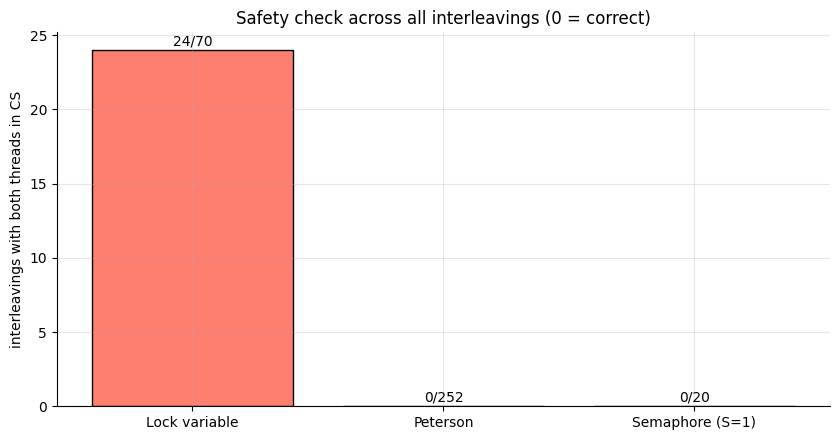

In [6]:
from itertools import permutations

# Generic interleaving generator: all orders of executing n0 steps of T0 and n1 of T1
def interleavings(n0, n1):
    from math import comb
    def gen(seq, a, b):
        if a==0 and b==0:
            yield seq; return
        if a>0:
            yield from gen(seq+[0], a-1, b)
        if b>0:
            yield from gen(seq+[1], a, b-1)
    yield from gen([], n0, n1)

def count_violations(frame_fn, steps_per_thread, **kw):
    bad=0; total=0
    for order in interleavings(steps_per_thread, steps_per_thread):
        total+=1
        frames = frame_fn(order, **kw) if kw else frame_fn(order)
        if any(f.get('violation') for f in frames): bad+=1
    return bad, total

# lock: 4 meaningful steps (test, set, enter, release); peterson: 5; semaphore: 3
lock_bad, lock_tot = count_violations(lambda o: lock_frames(o), 4)
pet_bad, pet_tot   = count_violations(lambda o: peterson_frames(o), 5)
sem_bad, sem_tot   = count_violations(lambda o: sem_frames(o, 1), 3)

names = ['Lock variable', "Peterson", 'Semaphore (S=1)']
bad = [lock_bad, pet_bad, sem_bad]; tot = [lock_tot, pet_tot, sem_tot]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(names, bad, color=['#fd7f6f','#b2e061','#7eb0d5'], edgecolor='k')
for b, v, t in zip(bars, bad, tot):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v}/{t}', ha='center', fontsize=10)
ax.set_ylabel('interleavings with both threads in CS')
ax.set_title('Safety check across all interleavings (0 = correct)')
plt.tight_layout(); plt.show()